<a href="https://colab.research.google.com/github/onipayedejohn/blood-cell-morphology-assistant/blob/main/notebooks/v1_single_lab_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blood cell morphology: from smear images to a checked classifier

This notebook walks through the whole project using the saved outputs, so it runs in a minute without retraining. Each step links to the script that did the work.

1. The data and how it was split
2. Preprocessing that is identical in training and in the app
3. Model comparison and the choice of input size
4. Test-set results, calibration and the "confident" rule
5. Where the model looks (class activation maps)
6. Images from another lab
7. What the mistakes look like, and what this model should not be used for

In [ ]:
import json, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src")); sys.path.insert(0, str(ROOT / "scripts"))
from bloodsmear.config import CLASSES, CELL_INFO, display_name
from bloodsmear.preprocess import resize_uint8
from bloodsmear.inference import CellClassifier
from bloodsmear.explain import overlay
MET = ROOT / "reports" / "metrics"
load = lambda n: json.loads((MET / n).read_text())
pd.set_option("display.precision", 3)

## 1. The data

PBC dataset (Acevedo et al., *Data in Brief*, 2020, CC BY 4.0): single cells photographed with a CellaVision DM96 in Barcelona, from donors without infection or blood disease. The copy used here has 13,344 images in 7 classes. `scripts/prepare_data.py` checks that every label matches its filename prefix, finds duplicates, and makes the split.

In [ ]:
man = pd.read_csv(ROOT / "data" / "manifest.csv")
summary = load("data_summary.json")
print(f"{summary['images']:,} images, {summary['exact_duplicates']} exact duplicates, {summary['groups']:,} duplicate groups")
counts = pd.crosstab(man["class"].map(display_name), man["split"], margins=True, margins_name="Total")[["train", "val", "test", "Total"]]
counts

13,344 images, 14 exact duplicates, 13,330 duplicate groups


split,train,val,test,Total
class,,,,
Basophil,752,107,214,1073
Eosinophil,2053,293,587,2933
Erythroblast (nucleated red cell),645,92,185,922
Immature granulocyte,1884,270,538,2692
Lymphocyte,813,116,232,1161
Monocyte,950,136,272,1358
Neutrophil,2243,321,641,3205
Total,9340,1335,2669,13344


In [ ]:
# No duplicate group and no identical image crosses a split boundary
assert (man.groupby("group")["split"].nunique() == 1).all()
assert (man.groupby("md5")["split"].nunique() == 1).all()
print("Duplicate groups stay inside one split.")
man.groupby("class")["subtype"].value_counts().rename("images").to_frame()

Duplicate groups stay inside one split.


images
class                subtype                                   
basophil             Basophil                              1073
eosinophil           Eosinophil                            2933
erythroblast         Erythroblast                           922
immature_granulocyte Myelocyte                             1069
                     Metamyelocyte                          959
                     Promyelocyte                           519
                     Immature granulocyte (unspecified)     145
lymphocyte           Lymphocyte                            1161
monocyte             Monocyte                              1358
neutrophil           Segmented neutrophil                  1594
                     Band neutrophil                       1561
                     Neutrophil (unspecified)                50

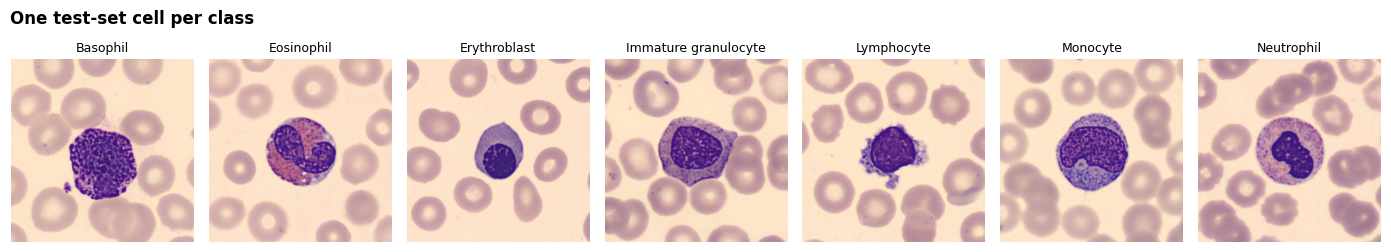

In [ ]:
samples = pd.read_csv(ROOT / "data" / "samples" / "samples.csv")
first = samples[samples["file"].str.endswith("_1.jpg")]
fig, axes = plt.subplots(1, 7, figsize=(14, 2.6))
for ax, r in zip(axes, first.itertuples()):
    ax.imshow(Image.open(ROOT / "data" / "samples" / r.file)); ax.set_title(display_name(r._2).split(" (")[0], fontsize=9); ax.axis("off")
plt.suptitle("One test-set cell per class", x=0.01, ha="left", fontweight="bold"); plt.tight_layout(); plt.show()

## 2. Preprocessing

One function, `bloodsmear.preprocess.resize_uint8`, crops the centre square and resizes with Lanczos filtering. The training arrays were built with it and the app calls it too, so the model never sees an image prepared differently. A test (`tests/test_data_and_model.py`) checks that re-running it on raw files reproduces the training arrays exactly.

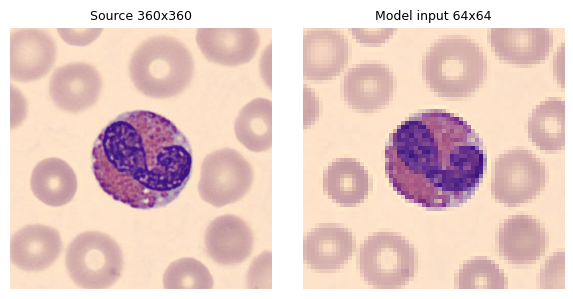

In [ ]:
meta = json.loads((ROOT / "models" / "model_meta.json").read_text())
size = meta["input_size"]
img = Image.open(ROOT / "data" / "samples" / "eosinophil_1.jpg")
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img); axes[0].set_title(f"Source {img.size[0]}x{img.size[1]}", fontsize=9)
axes[1].imshow(resize_uint8(img, size)); axes[1].set_title(f"Model input {size}x{size}", fontsize=9)
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()

## 3. Which model

Three candidates, compared on the **validation** set only:

- logistic regression on 24 x 24 pixels, as a no-learned-features baseline;
- a CNN at 64 x 64, the size used in the bootcamp notebook;
- a CNN at 112 x 112, to see whether finer granule detail helps.

The selection rule was written before training: keep 112 px only if it beats 64 px by more than 0.005 macro-F1. Batch-norm statistics are recomputed on clean images before every validation check (see `docs/decisions.md`, section 5).

In [ ]:
cmp = pd.DataFrame(load("model_comparison.json"))
print(meta["selection"]["reason"])
cmp[["name", "val_macro_f1", "val_accuracy", "params", "train_minutes", "train_energy_wh"]]

64 px scored +0.0009 macro-F1 against 112 px on validation, within the 0.005 tie margin, so the 64 px model was kept: it needs about 40% less computation per image (211 vs 366 million multiply-adds) and half the training energy


,name,val_macro_f1,val_accuracy,params,train_minutes,train_energy_wh
0,Logistic regression on 24x24 pixels,0.779,0.798,12103,0.31,0.064
1,"CNN, 64x64 input",0.992,0.990,1176935,40.30,10.760
2,"CNN, 112x112 input",0.991,0.989,663247,75.60,20.770


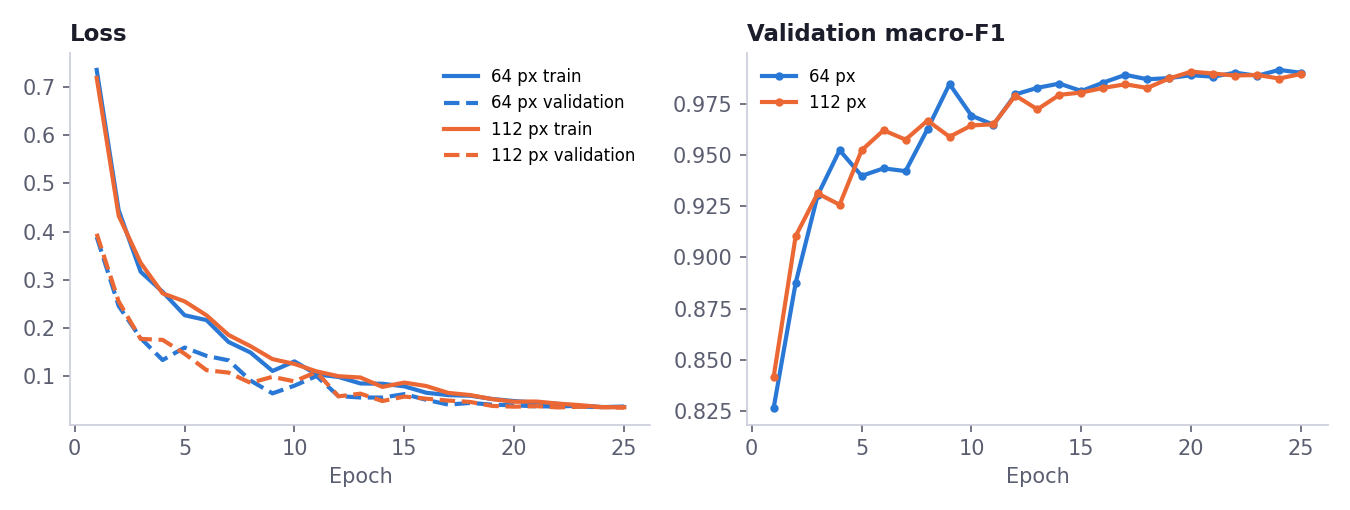

In [ ]:
from IPython.display import Image as Show
Show(filename=str(ROOT / "reports" / "figures" / "training_curves.png"), width=820)

## 4. Test-set results

The test set was split off before training and used only for final scoring by `scripts/evaluate.py` (twice: before and after the confidence-rule change in `docs/decisions.md`; the metrics below are the same in both runs). Confidence intervals are bootstrap percentiles (1,000 resamples).

In [ ]:
test = load("test_metrics.json")
rows = []
for k, name in [("accuracy", "Accuracy"), ("balanced_accuracy", "Balanced accuracy"), ("macro_f1", "Macro-F1")]:
    lo, hi = test[k + "_ci"]; rows.append({"Metric": name, "Value": test[k], "95% CI low": lo, "95% CI high": hi})
rows.append({"Metric": "ECE before calibration", "Value": test["ece_uncalibrated"]})
rows.append({"Metric": "ECE after temperature scaling", "Value": test["ece_calibrated"]})
pd.DataFrame(rows)

,Metric,Value,95% CI low,95% CI high
0,Accuracy,0.984,0.978,0.988
1,Balanced accuracy,0.985,0.980,0.990
2,Macro-F1,0.984,0.979,0.989
3,ECE before calibration,0.004,NaN,NaN
4,ECE after temperature scaling,0.005,NaN,NaN


In [ ]:
pc = pd.DataFrame(test["per_class"]); pc["class"] = pc["class"].map(display_name)
pc.sort_values("recall")

,class,precision,recall,f1,support
6,Neutrophil,0.994,0.969,0.981,641
3,Immature granulocyte,0.956,0.976,0.966,538
5,Monocyte,0.978,0.982,0.980,272
2,Erythroblast (nucleated red cell),0.979,0.989,0.984,185
0,Basophil,0.986,0.991,0.988,214
4,Lymphocyte,0.987,0.991,0.989,232
1,Eosinophil,1.000,1.000,1.000,587


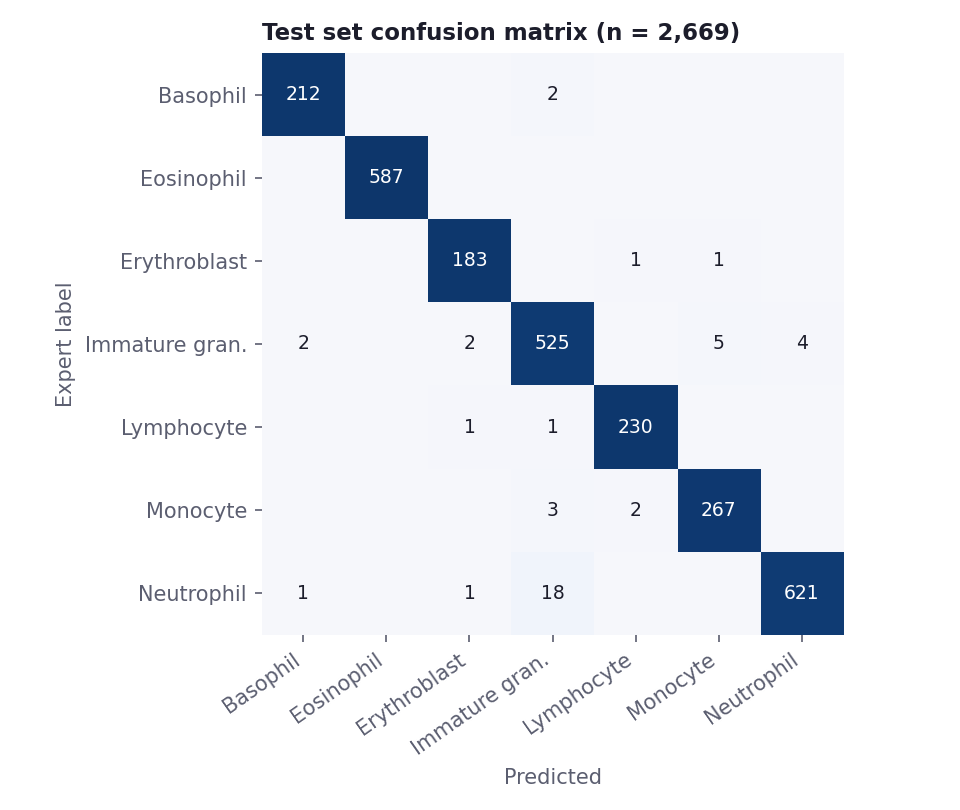

In [ ]:
Show(filename=str(ROOT / "reports" / "figures" / "confusion_matrix.png"), width=560)

In [ ]:
pd.DataFrame(test["subtypes"]).sort_values("recall")

,subtype,n,recall,most_common_error
0,Band neutrophil,323,0.947,immature_granulocyte
10,Promyelocyte,90,0.967,monocyte
6,Metamyelocyte,200,0.975,neutrophil
8,Myelocyte,222,0.977,basophil
7,Monocyte,272,0.982,immature_granulocyte
3,Erythroblast,185,0.989,lymphocyte
11,Segmented neutrophil,305,0.990,immature_granulocyte
1,Basophil,214,0.991,immature_granulocyte
5,Lymphocyte,232,0.991,erythroblast
2,Eosinophil,587,1.000,NaN


The largest group of errors sits between neighboring maturation stages: band neutrophils against metamyelocytes, and monocytes against immature granulocytes. Those boundaries are also where people disagree on a real smear.

### Calibration and the "confident" rule

In [ ]:
val = load("validation_choices.json"); sel = test["selective"]
print(f"Temperature {val['temperature']:.2f}. Confidence level {sel['confidence_threshold']:.0%}: sends the least confident "
      f"{val['review_budget']:.0%} of validation cells for review.")
print(f"Test: held back {sel['held_back']} cells ({sel['held_by_confidence']} low confidence, {sel['held_by_unfamiliar']} unfamiliar), "
      f"caught {sel['errors_held_back']} of {sel['errors']} errors; accepted cells {sel['accuracy_on_accepted']:.2%} correct.")
print(f"Still marked Confident: {sel['errors_marked_confident']} errors, {sel['errors_marked_confident_above_90']} of them above 90%.")
print("Rule history:", val["first_rule_replaced"]["test_effect"])

Temperature 0.92. Confidence level 81%: sends the least confident 2% of validation cells for review.
Test: held back 98 cells (70 low confidence, 30 unfamiliar), caught 25 of 44 errors; accepted cells 99.26% correct.
Still marked Confident: 19 errors, 10 of them above 90%.
Rule history: held back no test cells; all 30 held-back cells came from the unfamiliar-image check, and 42 of 44 test errors were marked Confident


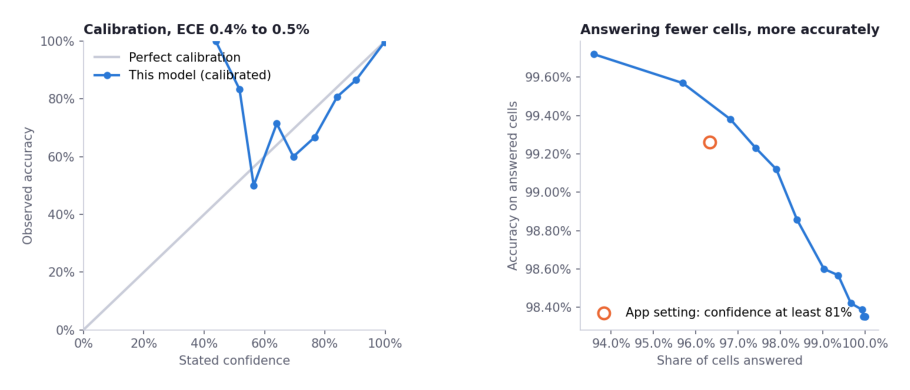

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, f in zip(axes, ["reliability.png", "selective_prediction.png"]):
    ax.imshow(Image.open(ROOT / "reports" / "figures" / f)); ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Where the model looks

The network ends in global average pooling and one dense layer, so the class activation map is exact: the last feature maps weighted by the dense weights for the predicted class. The app computes it from the ONNX model's second output.

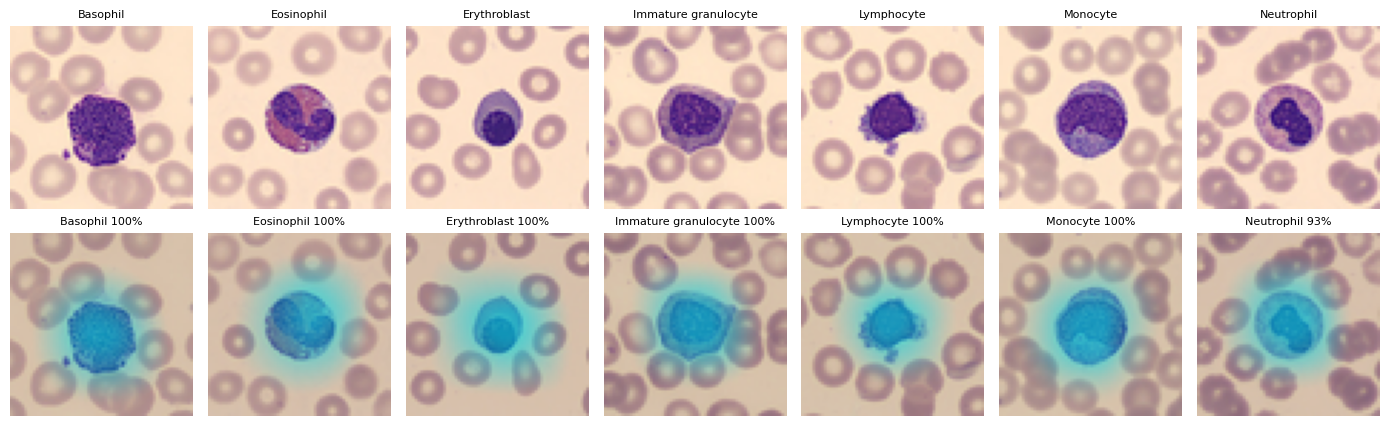

In [ ]:
clf = CellClassifier()
fig, axes = plt.subplots(2, 7, figsize=(14, 4.4))
for k, r in enumerate(first.itertuples()):
    p = clf.predict(Image.open(ROOT / "data" / "samples" / r.file))
    axes[0, k].imshow(p.image_uint8); axes[0, k].set_title(display_name(r._2).split(" (")[0], fontsize=8)
    axes[1, k].imshow(overlay(p.image_uint8, p.cam)); axes[1, k].set_title(f"{display_name(p.label).split(' (')[0]} {p.confidence:.0%}", fontsize=8)
for a in axes.flat: a.axis("off")
plt.tight_layout(); plt.show()

## 6. Images from another lab

BCCD photos come from a different lab, stain and camera, and have no subtype labels. So accuracy cannot be measured on them. What can be measured is whether the app notices they are different.

In [ ]:
ext = load("external_checks.json")
pd.DataFrame(ext["checks"]).T[["n", "flagged_unfamiliar"]]

,n,flagged_unfamiliar
bccd_white_cells,358.0,0.997
bccd_red_cells_only,150.0,1.000
random_noise,100.0,1.000
blank_fields,50.0,1.000
pbc_test_in_distribution,2669.0,0.011


What the model called the BCCD white cells: {'eosinophil': 2, 'erythroblast': 50, 'immature_granulocyte': 302, 'monocyte': 4}


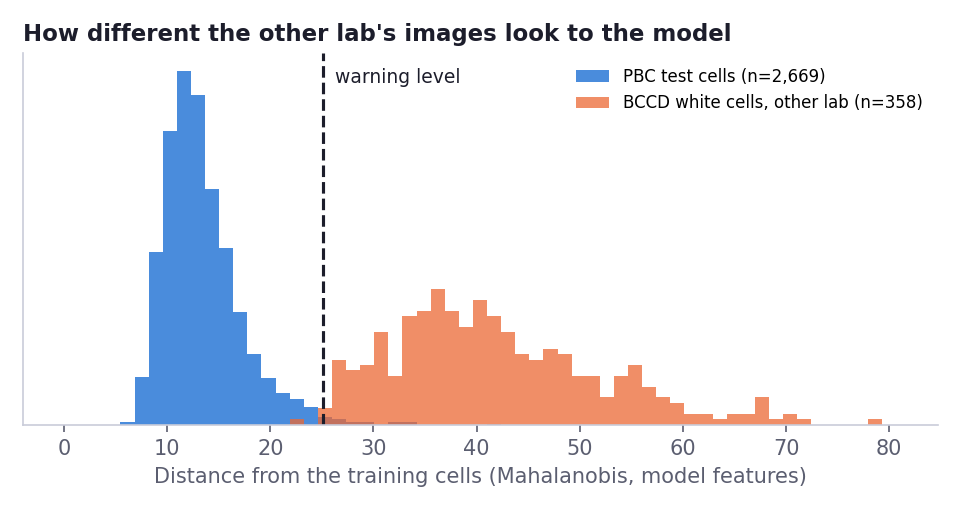

In [ ]:
print("What the model called the BCCD white cells:", ext["bccd_predicted_classes"])
Show(filename=str(ROOT / "reports" / "figures" / "unfamiliar_distances.png"), width=620)

## 7. Mistakes and limits

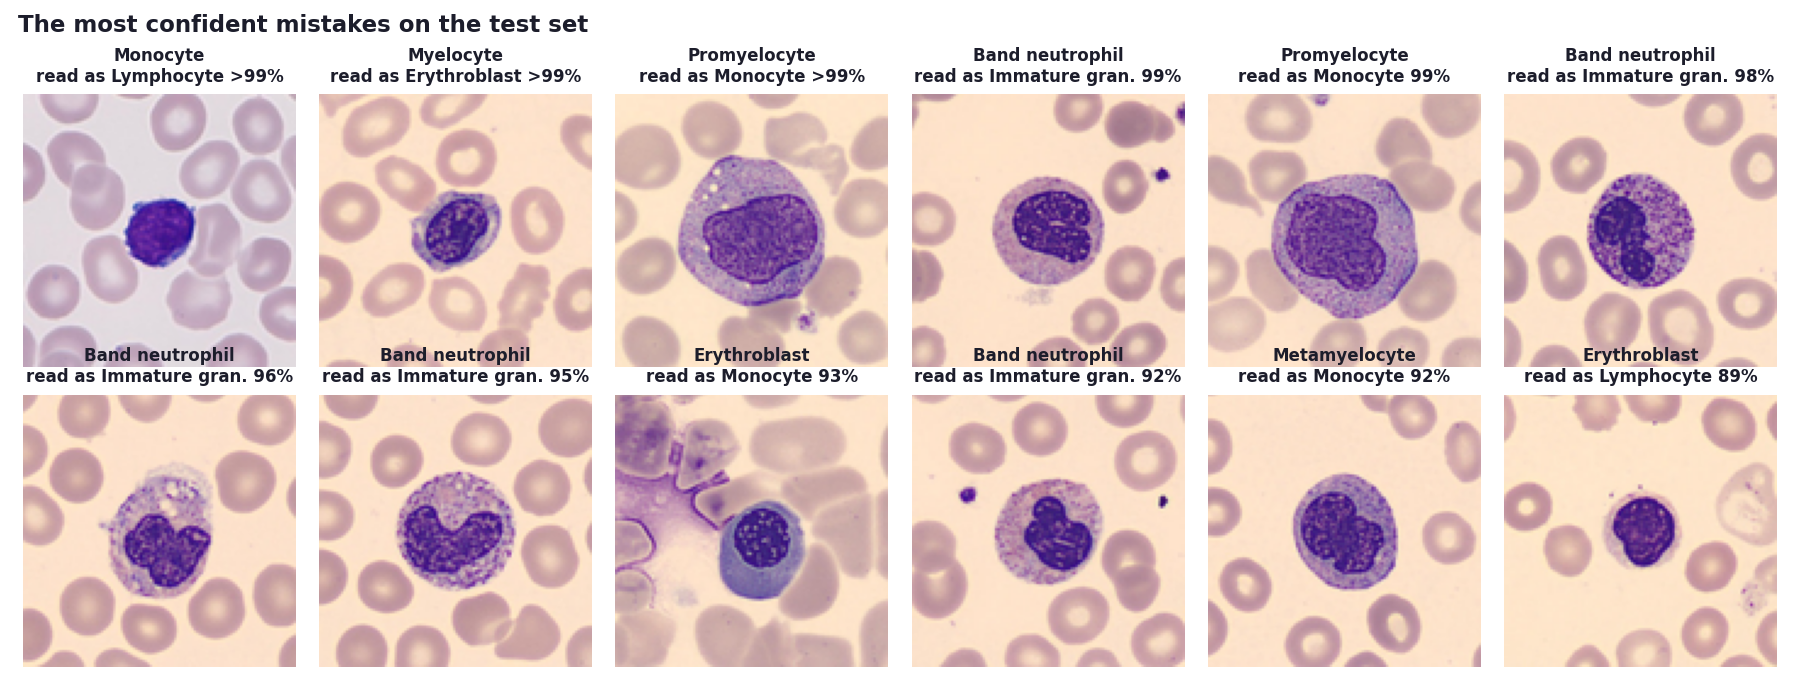

In [ ]:
Show(filename=str(ROOT / "reports" / "figures" / "confident_errors.png"), width=900)

**What this model should not be used for**

- Patient care. It is a research and teaching prototype, not a medical device.
- Images from other labs, stains, cameras or magnifications without checking the status line, and ideally without retraining.
- Abnormal cells: blasts, atypical lymphocytes, parasites and abnormal red cells are not classes here, and the model will force them into one of the seven.
- Whole smears: it classifies one cropped cell at a time.

The dataset has no patient identifiers, so test cells may come from the same people as training cells. Results on new patients are likely to be lower than those above.